# Examine ALE Plots 

- Observation: The ALE curve for $x_2$ for $f(x) = x_1 + x_1  x_2$ looks like a quadratic when $x_1,x_2$ are highly correlated.
    - No, rather we might expect it as the "average" in the dataset of $x_2$ as $x_3$ varies, that is, the ALE curve $f_{ALE,j}(x_2)=\mathbb{E}[X_1\mid X_2=x_2]x_2$. Since we can roughly estimate $\mathbb{E}[X_1\mid X_2=x_2]=x_2$ due to the high correlation, we would expect to see a quadratic curve.
    - This is the *correct inference*, as we should expect that as $x_2$ increases, the value of $f$ should increase due to both $x_2$ getting larger, and $x_1$ getting larger *because it tends to be larger with $x_2$.

- Observation: It seems like the main effects are somehow also capturing some interaction effects. For example, with highly correlated $X_1,X_2$, we have $f(x)=x_1+x_2+x_1x_2$ producing $ALE_{j,M}\approx ALE^Q_{j,T}$. Now that we observe the above example, this makes sense -- the ALE plot takes into account the interaction behavior and therefore the main effect does too.

- Observation: The VIM changes as the number of bins varies.

In [85]:
import numpy as np
import matplotlib.pyplot as plt

from algorithms.ale import ale_1d, ale_2d
from algorithms.ale_vim import ale_global_main, ale_connected_total, ale_connected_modified_total, ale_quantile_total

In [86]:
# generate data
def generate_2d_data(n, sigma=0.05):
    Z = np.random.uniform(-1, 1, n)
    epsilon_1 = np.random.normal(0, sigma, n)
    epsilon_2 = np.random.normal(0, sigma, n)
    X1 = Z + epsilon_1
    X2 = Z + epsilon_2

    # sample variance of X_1 * X_2
    product = X1 * X2
    print("Sample variance of x1 * x2:", np.var(product))

    return np.vstack([X1, X2]).T

def generate_2d_data_normal(n, rho=0.5):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_3d_data(n, sigma=0.05):
    Z = np.random.uniform(1, 2, n)
    epsilon_1 = np.random.normal(0, sigma, n)
    epsilon_2 = np.random.normal(0, sigma, n)
    epsilon_3 = np.random.normal(0, sigma, n)
    X1 = Z + epsilon_1
    X2 = Z + epsilon_2
    X3 = Z + epsilon_3
    return np.vstack([X1, X2, X3]).T

In [87]:
def replicate_ale_global_main(dgp, f, n, bins=20, replications=100):
    vim_1_mains = []
    vim_2_mains = []
    for _ in range(replications):
        X = dgp(n)
        edges1, curve1 = ale_1d(f, X, 1, bins=bins)
        edges2, curve2 = ale_1d(f, X, 2, bins=bins)
        vim_1_main = ale_global_main(edges1, curve1, X, 1)
        vim_2_main = ale_global_main(edges2, curve2, X, 2)
        vim_1_mains.append(vim_1_main)
        vim_2_mains.append(vim_2_main)

    # report CI
    print("VIM 1 Main Importance - Mean:", np.mean(vim_1_mains), "CI:", np.percentile(vim_1_mains, [2.5, 97.5]))
    print("VIM 2 Main Importance - Mean:", np.mean(vim_2_mains), "CI:", np.percentile(vim_2_mains, [2.5, 97.5]))

    return vim_1_mains, vim_2_mains

def replicate_ale_quantile_total(dgp, f, n, bins=20, replications=100):
    vim_1_totals = []
    vim_2_totals = []
    for _ in range(replications):
        X = dgp(n)
        vim_1_total = ale_quantile_total(f, X, 1, bins=bins)
        vim_2_total = ale_quantile_total(f, X, 2, bins=bins)
        vim_1_totals.append(vim_1_total)
        vim_2_totals.append(vim_2_total)

    # report CI
    print("VIM 1 Total Quantile Importance - Mean:", np.mean(vim_1_totals), "CI:", np.percentile(vim_1_totals, [2.5, 97.5]))
    print("VIM 2 Total Quantile Importance - Mean:", np.mean(vim_2_totals), "CI:", np.percentile(vim_2_totals, [2.5, 97.5]))

    return vim_1_totals, vim_2_totals

In [88]:
# Setting 1: main effects capture interaction effects
# setup: known model, highly correlated features (low sigma)
def f(x):
    return x[0] + x[1] + x[0] * x[1]
n = 1000
rho = 0.5
bins = 20
dgp = lambda n: generate_2d_data_normal(n, rho=rho)

# Setting 2: quadratic ALE curve for f(x) = x[0] + x[0] * x[1]
# setup: known model, highly correlated features (low sigma)
# def f(x):
#     return x[0] + x[1] # + x[0] * x[1]
# n = 2000
# rho = 0.5
# bins = 20
# dgp = lambda n: generate_2d_data(n, rho=rho)

X = dgp(n)
y = np.array([f(x) for x in X])

In [ ]:
## TODO: Speed this up!
vim_1_mains, vim_2_mains = replicate_ale_global_main(dgp, f, n=100, bins=bins, replications=1000)

VIM 1 Main Importance - Mean: 1.5140233322118317 CI: [0.76606526 2.75504929]
VIM 2 Main Importance - Mean: 1.5295693160772172 CI: [0.80173195 2.85558662]


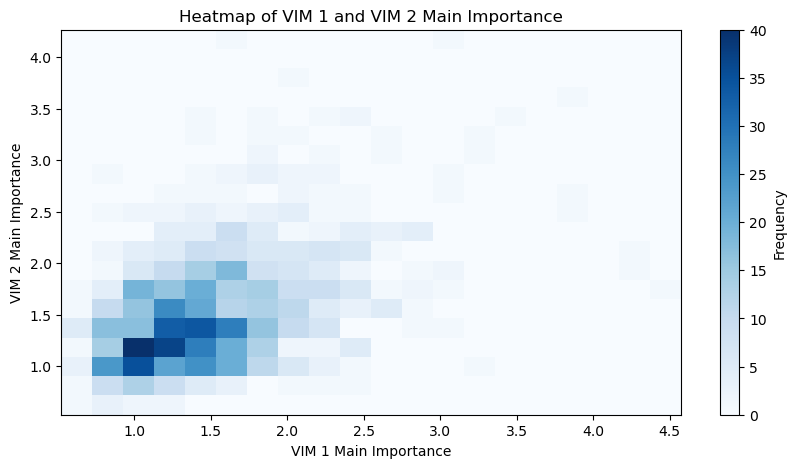

In [90]:
# plot heatmap of vim_1_mains and vim_2_mains
plt.figure(figsize=(10, 5))
plt.hist2d(vim_1_mains, vim_2_mains, bins=20, cmap='Blues')
plt.colorbar(label='Frequency')
plt.xlabel('VIM 1 Main Importance')
plt.ylabel('VIM 2 Main Importance')
plt.title('Heatmap of VIM 1 and VIM 2 Main Importance')
plt.show()

In [91]:
vim_1_total = ale_connected_total(f, X, 1, bins=bins)
vim_2_total = ale_connected_total(f, X, 2, bins=bins)
print(f"X1 Total Connected Importance: {round(vim_1_total, 3)}, X2 Total Connected Importance: {round(vim_2_total, 3)}")

X1 Total Connected Importance: 1.348, X2 Total Connected Importance: 1.153


In [92]:
edges1, curve1 = ale_1d(f, X, 1, bins=bins)
vim_1_main = ale_global_main(edges1, curve1, X, 1)
edges2, curve2 = ale_1d(f, X, 2, bins=bins)
vim_2_main = ale_global_main(edges1, curve1, X, 2)
vim_1_total = ale_quantile_total(f, X, 1, bins=bins)
vim_2_total = ale_quantile_total(f, X, 2, bins=bins)
print(f"X1 Main: {round(vim_1_main, 3)}, X2 Main: {round(vim_2_main, 3)}")
print(f"X1 Total Quantile Importance: {round(vim_1_total, 3)}, X2 Total Quantile Importance: {round(vim_2_total, 3)}")

X1 Main: 2.6, X2 Main: 2.717
X1 Total Quantile Importance: 3.581, X2 Total Quantile Importance: 4.038


In [93]:
vim_1_modified_total = ale_connected_modified_total(f, X, 1, bins=bins)
vim_2_modified_total = ale_connected_modified_total(f, X, 2, bins=bins)
print(f"X1 Total Modified Connected Importance: {round(vim_1_modified_total, 3)}, X2 Total Modified Connected Importance: {round(vim_2_modified_total, 3)}")

X1 Total Modified Connected Importance: 1.348, X2 Total Modified Connected Importance: 1.153


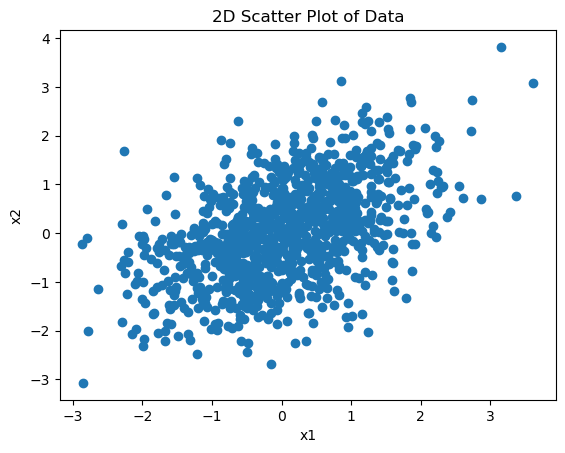

In [94]:
# 2d scatter plot
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Scatter Plot of Data")
plt.show()

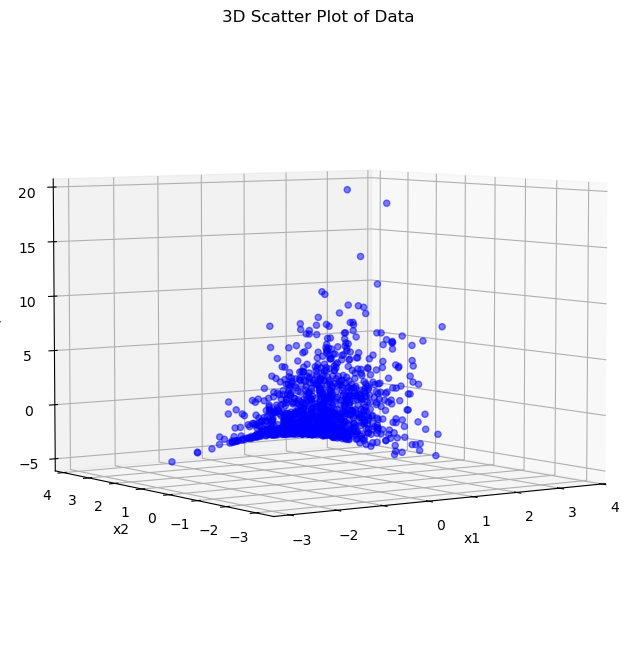

In [95]:
# 3d scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(5, 235)
ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', alpha=0.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Scatter Plot of Data')
plt.show()

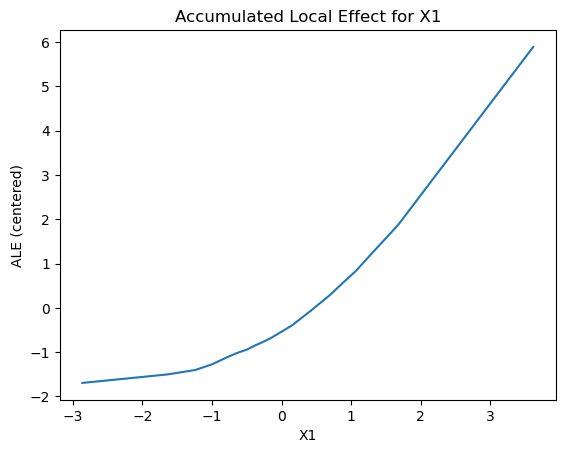

In [96]:
edges1, curve1 = ale_1d(f, X, 1, bins=bins)
plt.figure()
plt.plot(edges1, curve1)
plt.xlabel("X1")
plt.ylabel("ALE (centered)")
plt.title("Accumulated Local Effect for X1")
plt.show()

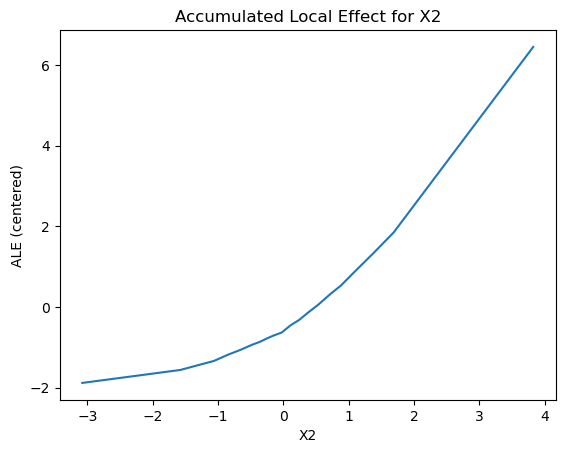

In [97]:
edges2, curve2 = ale_1d(f, X, 2, bins=bins)
plt.plot(edges2, curve2)
plt.xlabel("X2")
plt.ylabel("ALE (centered)")
plt.title("Accumulated Local Effect for X2")
plt.show()

In [98]:
# edges1_interaction, edges2_interaction, curve_interaction = ale_2d(f, X, 1, 2, bins=bins)
# edges1_mesh, edges2_mesh = np.meshgrid(edges1_interaction, edges2_interaction)
# plt.figure(figsize=(10, 8))
# # plot heatmap
# plt.pcolormesh(edges1_mesh, edges2_mesh, curve_interaction, shading='auto', cmap='viridis')
# plt.colorbar(label='ALE (centered)')
# plt.xlabel("X1")
# plt.ylabel("X2")
# plt.title("Accumulated Local Effect for Interaction between X1 and X2")
# plt.show()